# Cross-Section Property Calculator

Computes area, centroid, second moments of area, principal axes and section
moduli for composite cross-sections. Validated against a standard rolled profile.

Aadil Imran — Karlsruhe Institute of Technology, 2026

import numpy as np
print("ready")


## 1. Shape primitives

In [17]:
def rectangle(b, h, y=0.0, z=0.0):
    """
    b, h : width (along y) and height (along z), in mm
    y, z : where this rectangle's own centre sits, in mm
    Returns its area and second moments about its OWN centre.
    """
    return {
        "A":   b * h,
        "y":   y,
        "z":   z,
        "Iy":  b * h**3 / 12,
        "Iz":  h * b**3 / 12,
        "Iyz": 0.0, "b": b, "h":h
    }

In [18]:
r = rectangle(b=100, h=200)
print(r)

{'A': 20000, 'y': 0.0, 'z': 0.0, 'Iy': 66666666.666666664, 'Iz': 16666666.666666666, 'Iyz': 0.0, 'b': 100, 'h': 200}


## 2. Centroid of a composite section

In [32]:
def centroid(parts):
    """parts: a list of shape dictionaries."""
    A  = sum(p["A"] for p in parts)
    ys = sum(p["A"] * p["y"] for p in parts) / A
    zs = sum(p["A"] * p["z"] for p in parts) / A
    return A, ys, zs

In [33]:
ibeam = [
    rectangle(b=100, h=10,  y=0, z=+95),   # top flange
    rectangle(b=8,   h=180, y=0, z=0),     # web
    rectangle(b=100, h=10,  y=0, z=-95),   # bottom flange
]

A, ys, zs = centroid(ibeam)
print("A  =", A)
print("ys =", ys)
print("zs =", zs)

A  = 3440
ys = 0.0
zs = 0.0


## 3. Parallel-axis theorem

In [21]:
def section_properties(parts):
    A, ys, zs = centroid(parts)
    Iy = Iz = Iyz = 0.0
    for p in parts:
        dy = p["y"] - ys
        dz = p["z"] - zs
        Iy  += p["Iy"]  + p["A"] * dz**2
        Iz  += p["Iz"]  + p["A"] * dy**2
        Iyz += p["Iyz"] + p["A"] * dy * dz
    return {"A": A, "ys": ys, "zs": zs, "Iy": Iy, "Iz": Iz, "Iyz": Iyz}

In [22]:
props = section_properties(ibeam)
for k, v in props.items():
    print(f"{k:4s} = {v:,.2f}")

A    = 3,440.00
ys   = 0.00
zs   = 0.00
Iy   = 21,954,666.67
Iz   = 1,674,346.67
Iyz  = 0.00


## 4. Visualisation

In [23]:
def rectangle(b, h, y=0.0, z=0.0):
    return {
        "A":   b * h,
        "y":   y,
        "z":   z,
        "Iy":  b * h**3 / 12,
        "Iz":  h * b**3 / 12,
        "Iyz": 0.0,
        "b":   b,
        "h":   h,
    }

## 5. Worked example: symmetric I-section

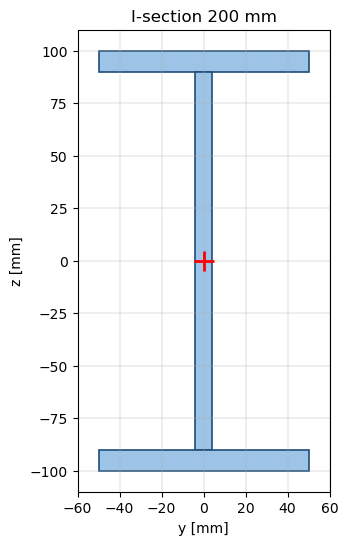

In [24]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle as MplRect

def plot_section(parts, props, title="Section"):
    fig, ax = plt.subplots(figsize=(4, 6))

    for p in parts:
        ax.add_patch(MplRect(
            (p["y"] - p["b"]/2, p["z"] - p["h"]/2),
            p["b"], p["h"],
            facecolor="#9dc3e6", edgecolor="#1f4e79", linewidth=1.2
        ))

    ax.plot(props["ys"], props["zs"], "r+", markersize=14, markeredgewidth=2)

    ys_all = [p["y"] - p["b"]/2 for p in parts] + [p["y"] + p["b"]/2 for p in parts]
    zs_all = [p["z"] - p["h"]/2 for p in parts] + [p["z"] + p["h"]/2 for p in parts]
    ax.set_xlim(min(ys_all) - 10, max(ys_all) + 10)
    ax.set_ylim(min(zs_all) - 10, max(zs_all) + 10)

    ax.set_aspect("equal")
    ax.set_xlabel("y [mm]")
    ax.set_ylabel("z [mm]")
    ax.set_title(title)
    ax.grid(True, linewidth=0.3)
    plt.show()

plot_section(ibeam, props, "I-section 200 mm")

## 6. Asymmetric sections: the product of inertia

A    = 1,900.00
ys   = 28.68
zs   = 28.68
Iy   = 1,800,043.86
Iz   = 1,800,043.86
Iyz  = -1,065,789.47


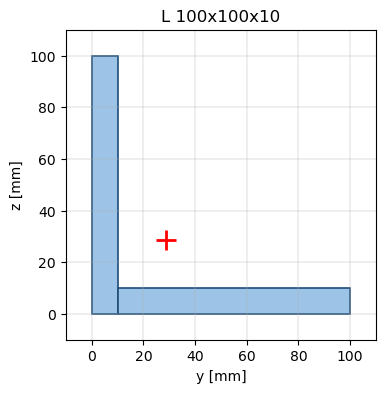

In [25]:
angle = [
    rectangle(b=10, h=100, y=5,  z=50),   # vertical leg
    rectangle(b=90, h=10,  y=55, z=5),    # horizontal leg
]

props_L = section_properties(angle)
for k, v in props_L.items():
    print(f"{k:4s} = {v:,.2f}")

plot_section(angle, props_L, "L 100x100x10")

In [26]:
import numpy as np

def principal_axes(props):
    J = np.array([[ props["Iy"], -props["Iyz"]],
                  [-props["Iyz"],  props["Iz"]]])
    eigenvalues, eigenvectors = np.linalg.eigh(J)
    I_min, I_max = eigenvalues
    v = eigenvectors[:, 1]                      # direction of I_max
    theta = np.degrees(np.arctan2(v[1], v[0]))
    return I_min, I_max, theta

In [27]:
I_min, I_max, theta = principal_axes(props_L)
print(f"I_min = {I_min:,.2f}")
print(f"I_max = {I_max:,.2f}")
print(f"theta = {theta:.2f} deg")
print(f"check: I_min + I_max = {I_min + I_max:,.2f}")
print(f"       Iy   + Iz     = {props_L['Iy'] + props_L['Iz']:,.2f}")

I_min = 734,254.39
I_max = 2,865,833.33
theta = 45.00 deg
check: I_min + I_max = 3,600,087.72
       Iy   + Iz     = 3,600,087.72


## 7. Principal axes

                model            table     error
A             2,724.8          2,848.0    -4.33%
Iy       18,455,902.3     19,400,000.0    -4.87%
Iz        1,419,344.8      1,420,000.0    -0.05%


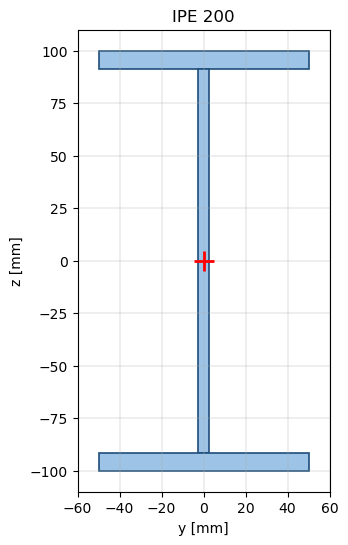

In [28]:
# IPE 200 modelled as three rectangles (root fillets omitted)
h, b, tw, tf = 200.0, 100.0, 5.6, 8.5
hw = h - 2*tf                      # clear web height

ipe200 = [
    rectangle(b=b,  h=tf, y=0, z=+(h - tf)/2),
    rectangle(b=tw, h=hw, y=0, z=0),
    rectangle(b=b,  h=tf, y=0, z=-(h - tf)/2),
]

p = section_properties(ipe200)
reference = {"A": 2848.0, "Iy": 19_400_000.0, "Iz": 1_420_000.0}

print(f"{'':4s} {'model':>16s} {'table':>16s} {'error':>9s}")
for k, ref in reference.items():
    err = (p[k] - ref) / ref * 100
    print(f"{k:4s} {p[k]:16,.1f} {ref:16,.1f} {err:8.2f}%")

plot_section(ipe200, p, "IPE 200")